[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/02_averaging_and_uncertainty.ipynb)

# 2. Averaging and the uncertainty of an estimate

**What you should get out of this notebook**

- Understand that an estimate computed from random data is itself a random variable, with a sampling distribution.
- Know why averaging $n$ measurements reduces the uncertainty by $\sqrt{n}$, and what the central limit theorem says.
- Construct and correctly interpret a confidence interval, using the $t$-distribution when the noise level is estimated from the data.
- Combine measurements of unequal quality with a weighted mean.
- Use the bootstrap to get uncertainties when no formula is available.

**Tools introduced**

- `np.mean`, `np.std(..., ddof=1)`, `np.average(..., weights=...)`
- `stats.sem`, `stats.t`, `stats.norm.interval`, `stats.t.interval`
- `stats.bootstrap`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## The problem

Suppose we measure a quantity $x$ repeatedly under nominally identical conditions and obtain $x_1, x_2, \dots, x_n$. The values differ because of random errors. What single value should we report, and what uncertainty should we attach to it?

We model the $i$th measurement as

$$
x_i = x + z_i,
$$

where $x$ is the true value and the errors $z_i$ are independent random variables with mean zero and standard deviation $\sigma$. (If the errors had a known non-zero mean, a *bias*, we would first subtract it.) We do **not** need to assume the errors are normally distributed for most of what follows, though we will start there.

## The sample mean and its sampling distribution

The obvious estimate is the arithmetic mean

$$
\hat{x} = \frac{1}{n}\sum_{i=1}^{n} x_i .
$$

The crucial idea is that $\hat{x}$ is a **random variable**. Repeat the whole experiment and you would get a different set of errors and hence a different $\hat{x}$. The distribution of $\hat{x}$ over such hypothetical repetitions is called its **sampling distribution**, and its properties are what tell us how good the estimate is. Two results follow directly from the rules for means and variances of sums of independent variables:

$$
E[\hat{x}] = x, \qquad \operatorname{sd}[\hat{x}] = \frac{\sigma}{\sqrt{n}} .
$$

The first says the sample mean is **unbiased**: on average it hits the true value. The second is the **standard error of the mean**: averaging $n$ measurements shrinks the noise by $\sqrt{n}$. To halve the uncertainty you need four times as many measurements.

Let us check these claims by simulation. We repeat an experiment of $n$ measurements many times and look at the distribution of the resulting sample means.

mean of the sample means      = 1.9992   (true value 2.0)
std of the sample means       = 0.0309   (σ/√n = 0.0316)


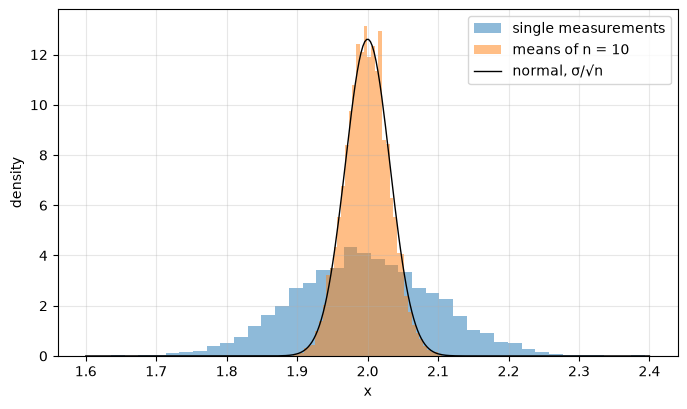

In [ ]:
x_true, sigma, n = 2.0, 0.1, 10
n_repeats = 5000

X = stats.norm(loc=x_true, scale=sigma)
data = X.rvs((n_repeats, n), random_state=rng)     # each row is one experiment of n measurements
means = data.mean(axis=1)

print(f"mean of the sample means      = {means.mean():.4f}   (true value {x_true})")
print(f"std of the sample means       = {means.std():.4f}   (σ/√n = {sigma/np.sqrt(n):.4f})")

fig, ax = plt.subplots()
ax.hist(data[:, 0], bins=40, density=True, alpha=0.5, label="single measurements")
ax.hist(means, bins=40, density=True, alpha=0.5, label=f"means of n = {n}")
xx = np.linspace(1.6, 2.4, 300)
ax.plot(xx, stats.norm(x_true, sigma/np.sqrt(n)).pdf(xx), "k", lw=1, label="normal, σ/√n")
ax.set(xlabel="x", ylabel="density"); ax.legend()
plt.show()

The sample means are much more tightly clustered around the true value than individual measurements, and their spread agrees with $\sigma/\sqrt{n}$.

Notice the way the simulation is organised: a two-dimensional array with one experiment per row, then `mean(axis=1)`. This vectorised pattern is far faster than a Python loop and will be used repeatedly.

## The central limit theorem

In the simulation above the errors were normal, and the histogram of means was normal too. What if the errors are not normal? The **central limit theorem (CLT)** says that the sum (or mean) of $n$ independent random variables with finite variance tends towards a normal distribution as $n$ grows, *whatever the distribution of the individual terms*. This is why the normal distribution is everywhere: measurement errors are usually the sum of many small contributions.

Below we average $n$ samples from a very non-normal distribution, an exponential, for several $n$.

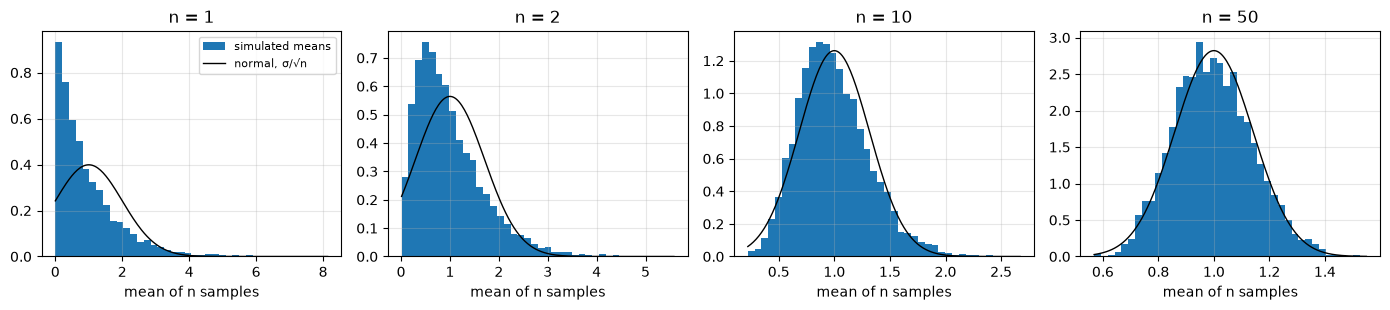

In [ ]:
E = stats.expon(scale=1.0)          # mean 1, standard deviation 1, strongly skewed
fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
for a, n in zip(ax, [1, 2, 10, 50]):
    means = E.rvs((5000, n), random_state=rng).mean(axis=1)
    a.hist(means, bins=40, density=True, label="simulated means")
    xx = np.linspace(means.min(), means.max(), 200)
    a.plot(xx, stats.norm(E.mean(), E.std()/np.sqrt(n)).pdf(xx), "k", lw=1, label="normal, σ/√n")
    a.set(title=f"n = {n}", xlabel="mean of n samples")
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

With $n = 1$ we see the exponential itself. By $n = 10$ the mean is already close to normal, and by $n = 50$ the agreement is excellent. The standard error formula $\sigma/\sqrt{n}$ holds exactly for every $n$ (it does not rely on normality); the CLT adds that the *shape* becomes normal. There are exceptions: distributions with infinite variance (very heavy tails) do not obey the CLT, and averaging then does not help in the usual way. Such distributions are rare in measurement error but do arise in nature, for example in the sizes of earthquakes and floods.

## Confidence intervals

Because $\hat{x}$ is approximately normal with standard deviation $\sigma/\sqrt{n}$, we know that in 95% of repetitions $\hat{x}$ falls within $1.96\,\sigma/\sqrt{n}$ of the true value $x$. Turning this around, the interval

$$
\hat{x} \pm 1.96\,\frac{\sigma}{\sqrt{n}}
$$

contains the true value in 95% of repetitions. This is a **95% confidence interval**. The factor 1.96 is the 0.975-quantile of the standard normal; for a 99% interval it would be 2.58.

The interpretation needs care. The true value $x$ is fixed; it is the *interval* that is random, because it is built from random data. "95% confidence" is a statement about the procedure: it captures the truth 95% of the time. It is **not** the probability that this particular interval contains the true value, which in the frequentist framework is either 0 or 1. (Notebook 7 shows how the Bayesian framework lets one make probability statements about the parameter itself.)

Let us verify the coverage claim by simulation, and draw the first 50 intervals.

fraction of intervals containing the true value: 0.950


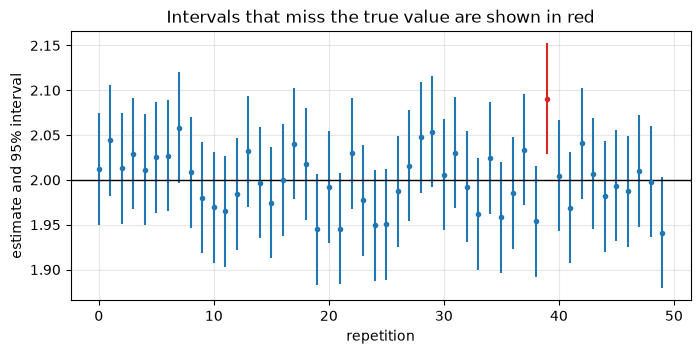

In [ ]:
x_true, sigma, n = 2.0, 0.1, 10
n_repeats = 2000
data = stats.norm(x_true, sigma).rvs((n_repeats, n), random_state=rng)
means = data.mean(axis=1)
half = 1.96 * sigma / np.sqrt(n)
covered = np.abs(means - x_true) < half
print(f"fraction of intervals containing the true value: {covered.mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(50):
    ax.errorbar(i, means[i], yerr=half, fmt="o", ms=3, color="C0" if covered[i] else "C3")
ax.axhline(x_true, color="k", lw=1)
ax.set(xlabel="repetition", ylabel="estimate and 95% interval", title="Intervals that miss the true value are shown in red")
plt.show()

### When $\sigma$ is unknown: the $t$-distribution

Usually we do not know $\sigma$ in advance, and must estimate it from the same data using the sample standard deviation

$$
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \hat{x})^2}.
$$

The estimated standard error is then $s/\sqrt{n}$. But $s$ is itself uncertain, particularly for small $n$, and this extra uncertainty widens the interval. The correct result (for normal errors) is that

$$
\frac{\hat{x} - x}{s/\sqrt{n}}
$$

follows **Student's $t$-distribution** with $\nu = n - 1$ degrees of freedom. The $t$-distribution looks like a normal with heavier tails, and the tails get heavier as $\nu$ decreases. A confidence interval is then

$$
\hat{x} \pm t_{\nu,\,0.975}\,\frac{s}{\sqrt{n}},
$$

where $t_{\nu,0.975}$ is the 0.975-quantile of $t_\nu$. For $\nu = 4$ this is 2.78 rather than 1.96; by $\nu = 30$ it is 2.04 and the distinction rarely matters.

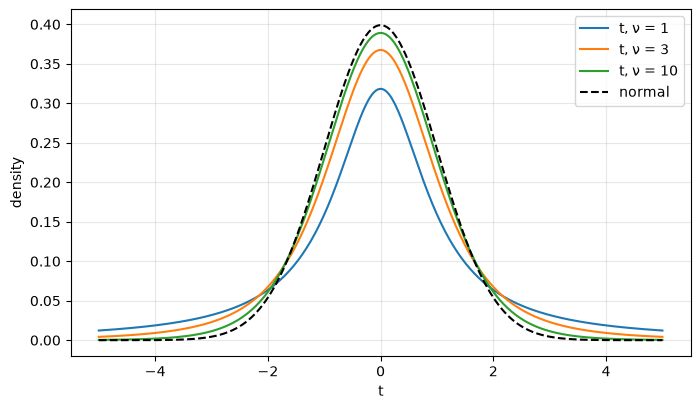

0.975-quantile of t for ν = 2, 4, 10, 30, 100:
[4.303 2.776 2.228 2.042 1.984]


In [ ]:
xx = np.linspace(-5, 5, 400)
fig, ax = plt.subplots()
for nu in [1, 3, 10]:
    ax.plot(xx, stats.t(nu).pdf(xx), label=f"t, ν = {nu}")
ax.plot(xx, stats.norm().pdf(xx), "k--", label="normal")
ax.set(xlabel="t", ylabel="density"); ax.legend()
plt.show()

print("0.975-quantile of t for ν = 2, 4, 10, 30, 100:")
print(np.round(stats.t([2, 4, 10, 30, 100]).ppf(0.975), 3))

Here is the complete recipe for a confidence interval from a small sample, using the `scipy.stats` helpers. `stats.sem` computes $s/\sqrt{n}$; `stats.t.interval` does the rest.

In [ ]:
sample = stats.norm(2.0, 0.1).rvs(6, random_state=rng)      # six measurements
xhat = sample.mean()
se = stats.sem(sample)                                       # = np.std(sample, ddof=1) / np.sqrt(len(sample))
lo, hi = stats.t.interval(0.95, df=len(sample) - 1, loc=xhat, scale=se)

print("measurements:", np.round(sample, 3))
print(f"estimate = {xhat:.4f} ± {se:.4f} (standard error)")
print(f"95% confidence interval (t): [{lo:.4f}, {hi:.4f}]")
lo_n, hi_n = stats.norm.interval(0.95, loc=xhat, scale=se)
print(f"95% interval using normal instead (too narrow): [{lo_n:.4f}, {hi_n:.4f}]")

measurements: [2.156 2.02  2.081 2.184 1.786 1.853]
estimate = 2.0132 ± 0.0662 (standard error)
95% confidence interval (t): [1.8431, 2.1834]
95% interval using normal instead (too narrow): [1.8835, 2.1430]


Exercise 2 asks you to confirm by simulation that the normal-based interval under-covers at small $n$ while the $t$-based interval does not.

A note on reporting. The convention "$\hat{x} \pm \delta$" is ambiguous unless you say what $\delta$ is: one standard error, a 95% interval, or something else. Always state which.

## Measurements of unequal quality: the weighted mean

Suppose the measurements have *different* uncertainties $\sigma_i$, for example because they come from different instruments or laboratories. Giving each measurement equal weight would waste information in the precise ones. The optimal combination weights each datum by its inverse variance:

$$
\hat{x} = \frac{\sum_i w_i x_i}{\sum_i w_i}, \qquad w_i = \frac{1}{\sigma_i^2},
\qquad
\operatorname{sd}[\hat{x}] = \frac{1}{\sqrt{\sum_i w_i}} .
$$

If all the $\sigma_i$ are equal this reduces to the ordinary mean and $\sigma/\sqrt{n}$. Among all unbiased linear combinations of the data, the inverse-variance weighted mean has the smallest variance. `np.average` takes a `weights` argument. Note that a single very precise measurement can dominate the result: the weighted mean *trusts the stated uncertainties*, so they had better be right.

In [ ]:
# Three laboratories measure the same isotope ratio with different precision
values = np.array([0.7102, 0.7095, 0.7110])
sigmas = np.array([0.0002, 0.0010, 0.0005])
w = 1 / sigmas**2

xhat = np.average(values, weights=w)
sd = 1 / np.sqrt(w.sum())
print(f"weighted mean   = {xhat:.5f} ± {sd:.5f}")
print(f"unweighted mean = {values.mean():.5f} ± {values.std(ddof=1)/np.sqrt(3):.5f}")
print("relative weights:", np.round(w / w.sum(), 3))

weighted mean   = 0.71028 ± 0.00018
unweighted mean = 0.71023 ± 0.00043
relative weights: [0.833 0.033 0.133]


The weighted mean here is essentially the first laboratory's value, because it is five times more precise than the third and twenty-five times more precise than the second, and weight goes as the *square* of precision.

A hidden assumption in both the ordinary and weighted mean is that the errors are **independent**. If the measurements share a common error (all made with the same miscalibrated instrument, say), averaging cannot remove it, and the formulae above overstate the precision. Handling correlated errors needs the full covariance matrix, which appears in Notebook 3.

## The bootstrap: uncertainty without formulae

The formula $\sigma/\sqrt{n}$ is specific to the mean. What is the standard error of the median? Of the standard deviation itself? Of a fitted slope, or a correlation coefficient? Formulae exist for some of these, under assumptions, but there is a general-purpose computational method that works for almost any statistic: the **bootstrap**.

The idea is to mimic "repeating the experiment" using the data we have. We draw a new sample of size $n$ *with replacement* from the observed values, compute the statistic, and repeat many times. The spread of the resulting values estimates the sampling distribution of the statistic. It works because the empirical distribution of the data is our best estimate of the distribution that generated them.

`scipy.stats.bootstrap` implements this. We ask for the simple `"percentile"` interval, which takes the 2.5% and 97.5% quantiles of the bootstrap values; the default `"BCa"` method is a refinement that is usually better, but it can fail for statistics such as the median of integer-valued data. Here we apply the bootstrap to the Old Faithful waiting times from Notebook 1, first to the mean (where we can compare with the formula) and then to the median.

mean   = 70.90,  bootstrap standard error = 0.83,  95% CI = [69.25, 72.50]
median = 76.00,  bootstrap standard error = 1.00,  95% CI = [73.50, 77.00]

formula for the mean: standard error = 0.82


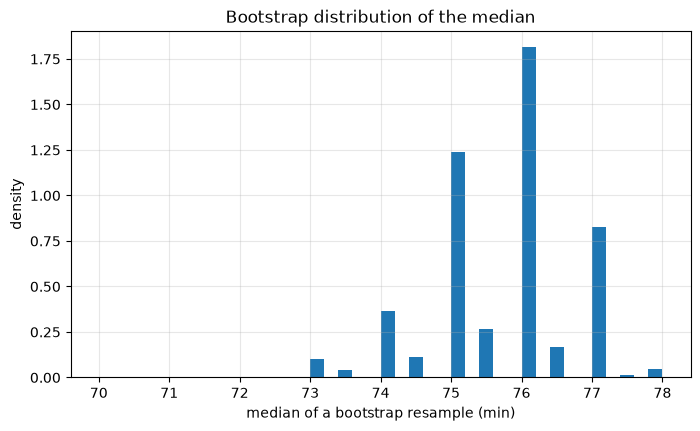

In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
waiting = faithful["waiting"].to_numpy()

for statistic in [np.mean, np.median]:
    res = stats.bootstrap((waiting,), statistic, n_resamples=5000, confidence_level=0.95,
                          method="percentile", random_state=rng)
    print(f"{statistic.__name__:6s} = {statistic(waiting):.2f},  bootstrap standard error = {res.standard_error:.2f},"
          f"  95% CI = [{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}]")

print(f"\nformula for the mean: standard error = {stats.sem(waiting):.2f}")

fig, ax = plt.subplots()
ax.hist(res.bootstrap_distribution, bins=40, density=True)
ax.set(xlabel="median of a bootstrap resample (min)", ylabel="density", title="Bootstrap distribution of the median")
plt.show()

For the mean, the bootstrap reproduces the formula. For the median it gives an answer where no simple formula exists, and the histogram shows something worth understanding: the bootstrap distribution of the median is lumpy because the waiting times were recorded in whole minutes, so the median of any resample can only be an integer or a half-integer. The bootstrap faithfully reflects such features of the data. The bootstrap is treated in more depth in Notebook 8. Its main requirement is that the data be independent, which fails for time series and spatially clustered samples.

## Summary

- An estimate computed from noisy data is a random variable; its sampling distribution determines its uncertainty.
- The sample mean is unbiased with standard error $\sigma/\sqrt{n}$; by the central limit theorem it is approximately normal for moderate $n$ regardless of the error distribution.
- A 95% confidence interval is a procedure that captures the true value in 95% of repetitions. Use the $t$-distribution when $\sigma$ is estimated from the data.
- Measurements of unequal precision are combined with inverse-variance weights.
- The bootstrap estimates the uncertainty of almost any statistic by resampling the data.

## Exercises

### Exercise 1

A gravimeter reading has a standard deviation of 0.05 mGal. How many readings must be averaged to bring the standard error below 0.01 mGal? Check your answer by simulation with `stats.norm`.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

We need $\sigma/\sqrt{n} < 0.01$, i.e. $n > (0.05/0.01)^2 = 25$, so 26 or more.

```python
sigma = 0.05
for n in [25, 26, 30]:
    means = stats.norm(0, sigma).rvs((10_000, n), random_state=rng).mean(axis=1)
    print(f"n = {n}: standard error by formula {sigma/np.sqrt(n):.4f}, by simulation {means.std():.4f}")
```

</details>

### Exercise 2

For $n = 5$ normal measurements with unknown $\sigma$, construct 95% confidence intervals from 10,000 simulated experiments in two ways: using the normal quantile 1.96 and using the $t$ quantile with 4 degrees of freedom, in both cases with the standard error estimated by $s/\sqrt{n}$. What fraction of intervals of each type contains the true value? Repeat for $n = 30$.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
for n in [5, 30]:
    data = stats.norm(0, 1).rvs((10_000, n), random_state=rng)
    xhat = data.mean(axis=1)
    se = data.std(axis=1, ddof=1) / np.sqrt(n)
    for name, q in [("normal", stats.norm.ppf(0.975)), ("t", stats.t(n - 1).ppf(0.975))]:
        coverage = np.mean(np.abs(xhat) < q * se)
        print(f"n = {n:2d}, {name:6s} quantile {q:.3f}: coverage = {coverage:.3f}")
```

At $n = 5$ the normal-based interval contains the truth only about 88% of the time rather than 95%; the $t$ interval achieves the nominal 95%. At $n = 30$ both are close to 95%.

</details>

### Exercise 3

Use `stats.bootstrap` to find a 95% confidence interval for the *standard deviation* of the waiting times after long eruptions (`duration >= 3`). Compare with the interval for the standard deviation of *all* waiting times. Why is the second so much wider in relative terms?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
duration = faithful["eruptions"].to_numpy()
long_ = waiting[duration >= 3]
sd = lambda x: np.std(x, ddof=1)
for name, x in [("long eruptions", long_), ("all", waiting)]:
    res = stats.bootstrap((x,), sd, n_resamples=5000, random_state=rng)
    ci = res.confidence_interval
    print(f"{name:15s}: s = {sd(x):.2f}, 95% CI = [{ci.low:.2f}, {ci.high:.2f}], n = {len(x)}")
```

The standard deviation of all waiting times is dominated by the separation of the two clusters rather than by scatter within a cluster. Resampling changes the proportion of short and long waits in each bootstrap sample, and that moves the overall standard deviation around a good deal. For a single cluster the standard deviation is a stable property of a roughly normal distribution and is estimated much more precisely.

</details>